<a href="https://colab.research.google.com/github/Dani2003/paper-implementations/blob/main/lisat_geospatial_reasoning_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# [CELL 1 - Setup Environment and Install Dependencies]
import os
import sys
import time
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple, List, Dict, Optional, Set

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Set random seed for reproducible benchmarks
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Compute Device: {device}")
print("Environment successfully initialized.")

Using Compute Device: cpu
Environment successfully initialized.


In [2]:
# [CELL 2 - Synthetic Satellite Imagery & Complex Reasoning Prompt Generator]

class SyntheticGeospatialDataset:
    """
    Simulates remote-sensing satellite imagery (128x128 RGB) with diverse geospatial objects
    (e.g., solar arrays, water bodies, agricultural fields) and complex text prompts.
    """
    def __init__(self, num_samples: int = 120, img_size: int = 128):
        self.num_samples = num_samples
        self.img_size = img_size
        self.prompts = [
            "Segment the solar panel arrays adjacent to the agricultural region.",
            "Identify and segment all water bodies near urban structures.",
            "Locate and segment high-density vegetation zones."
        ]

    def generate_data(self) -> Tuple[torch.Tensor, torch.Tensor, List[str]]:
        images = []
        masks = []
        prompt_list = []

        for i in range(self.num_samples):
            # Base satellite texture (background terrain)
            img = np.random.uniform(0.2, 0.5, (3, self.img_size, self.img_size)).astype(np.float32)
            mask = np.zeros((1, self.img_size, self.img_size), dtype=np.float32)

            prompt_idx = i % len(self.prompts)
            selected_prompt = self.prompts[prompt_idx]

            if prompt_idx == 0:  # Solar panel arrays
                r_start, c_start = np.random.randint(20, 60), np.random.randint(20, 60)
                h, w = np.random.randint(25, 40), np.random.randint(25, 40)
                img[2, r_start:r_start+h, c_start:c_start+w] += 0.4  # Blueish tint
                mask[0, r_start:r_start+h, c_start:c_start+w] = 1.0

            elif prompt_idx == 1:  # Water bodies
                r_start, c_start = np.random.randint(10, 50), np.random.randint(10, 50)
                h, w = np.random.randint(30, 50), np.random.randint(30, 50)
                img[0, r_start:r_start+h, c_start:c_start+w] -= 0.1
                img[1, r_start:r_start+h, c_start:c_start+w] += 0.2
                mask[0, r_start:r_start+h, c_start:c_start+w] = 1.0

            else:  # High-density vegetation
                r_start, c_start = np.random.randint(30, 70), np.random.randint(30, 70)
                h, w = np.random.randint(20, 45), np.random.randint(20, 45)
                img[1, r_start:r_start+h, c_start:c_start+w] += 0.5  # Greenish tint
                mask[0, r_start:r_start+h, c_start:c_start+w] = 1.0

            images.append(img)
            masks.append(mask)
            prompt_list.append(selected_prompt)

        images_tensor = torch.tensor(np.stack(images), dtype=torch.float32)
        masks_tensor = torch.tensor(np.stack(masks), dtype=torch.float32)

        return images_tensor, masks_tensor, prompt_list

dataset_gen = SyntheticGeospatialDataset(num_samples=150, img_size=128)
geo_images, geo_masks, geo_prompts = dataset_gen.generate_data()

print(f"Dataset generated: {geo_images.shape[0]} satellite images {geo_images.shape[1:]}")
print(f"Ground Truth Masks: {geo_masks.shape}")
print(f"Sample Prompt: '{geo_prompts[0]}'")

Dataset generated: 150 satellite images torch.Size([3, 128, 128])
Ground Truth Masks: torch.Size([150, 1, 128, 128])
Sample Prompt: 'Segment the solar panel arrays adjacent to the agricultural region.'


In [3]:
# [CELL 3 - LISAT Architecture: Vision Encoder + Prompt Reasoning + Mask Decoder]

class GeospatialVisionEncoder(nn.Module):
    """Convolutional Vision Backbone extracting dense multi-scale spatial feature maps."""
    def __init__(self, in_channels: int = 3, embed_dim: int = 256):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, stride=2, padding=1), # 64x64
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),        # 32x32
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, embed_dim, kernel_size=3, stride=2, padding=1), # 16x16
            nn.BatchNorm2d(embed_dim),
            nn.ReLU()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.stem(x)


class SimplePromptEncoder(nn.Module):
    """Maps text prompts to a dense reasoning embedding vector v_seg."""
    def __init__(self, embed_dim: int = 256):
        super().__init__()
        # Hash lookup simulation for reasoning embeddings
        self.embedding = nn.Embedding(100, embed_dim)
        self.fc = nn.Linear(embed_dim, embed_dim)

    def forward(self, prompt_indices: torch.Tensor) -> torch.Tensor:
        x = self.embedding(prompt_indices)
        return F.relu(self.fc(x))


class LISATSegmentationModel(nn.Module):
    """
    LISAT Framework: Fuses dense satellite feature maps with reasoning [SEG] prompt embeddings
    via cross-attentive dot product, decoding into full-resolution binary segmentation masks.
    """
    def __init__(self, embed_dim: int = 256):
        super().__init__()
        self.vision_encoder = GeospatialVisionEncoder(in_channels=3, embed_dim=embed_dim)
        self.prompt_encoder = SimplePromptEncoder(embed_dim=embed_dim)

        # Transposed convolutional mask decoder (16x16 -> 128x128)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(embed_dim + 1, 128, kernel_size=4, stride=2, padding=1), # 32x32
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),           # 64x64
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),            # 128x128
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 1, kernel_size=3, padding=1)                                 # Binary mask logits
        )

    def forward(self, images: torch.Tensor, prompt_indices: torch.Tensor) -> torch.Tensor:
        # Extract visual feature map: (B, C, H_feat, W_feat) -> (B, 256, 16, 16)
        vis_features = self.vision_encoder(images)
        B, C, H_f, W_f = vis_features.shape

        # Extract text reasoning embedding: (B, 256)
        seg_embedding = self.prompt_encoder(prompt_indices)

        # Compute cross-attentive feature interaction map
        # (B, 256, 16, 16) * (B, 256, 1, 1) -> (B, 1, 16, 16)
        seg_embed_expanded = seg_embedding.view(B, C, 1, 1)
        interaction_map = torch.sum(vis_features * seg_embed_expanded, dim=1, keepdim=True)

        # Concatenate spatial vision features with interaction map
        fused_features = torch.cat([vis_features, interaction_map], dim=1) # (B, 257, 16, 16)

        # Decode into output logit mask
        mask_logits = self.decoder(fused_features)
        return mask_logits

print("LISAT Architecture successfully initialized.")

LISAT Architecture successfully initialized.


In [4]:
# [CELL 4 - Loss Functions & Generalized IoU (gIoU) Evaluator]

class CombinedSegLoss(nn.Module):
    """Combines Binary Cross-Entropy (BCE) and Soft Dice Loss for robust mask optimization."""
    def __init__(self, smooth: float = 1.0):
        super().__init__()
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        bce_loss = self.bce(logits, targets)

        probs = torch.sigmoid(logits)
        intersection = (probs * targets).sum(dim=(2, 3))
        cardinality = probs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))

        dice_loss = 1.0 - (2.0 * intersection + self.smooth) / (cardinality + self.smooth)
        return bce_loss + dice_loss.mean()


def compute_giou_and_ciou(pred_masks: torch.Tensor, gt_masks: torch.Tensor, threshold: float = 0.5) -> Tuple[float, float]:
    """
    Computes generalized IoU (gIoU) and cumulative IoU (cIoU) across batch outputs.
    gIoU penalizes non-overlapping predicted bounding spaces.
    """
    preds = (torch.sigmoid(pred_masks) > threshold).float()

    intersection = (preds * gt_masks).sum(dim=(1, 2, 3))
    union = (preds + gt_masks - preds * gt_masks).sum(dim=(1, 2, 3))

    # Standard IoU per sample
    iou = (intersection + 1e-7) / (union + 1e-7)

    # Generalized IoU approximation penalty for convex hull area
    giou = iou - ((union - intersection) / (union + 1e-7))

    c_iou = intersection.sum() / (union.sum() + 1e-7)

    return float(giou.mean().item()), float(c_iou.item())

print("Loss Engine & gIoU/cIoU Metrics Configured.")

Loss Engine & gIoU/cIoU Metrics Configured.


In [5]:
# [CELL 5 - Optimization Loop: Training LISAT on Geospatial Tasks]

# Map text prompts to dummy integer prompt IDs
prompt_mapping = {p: idx for idx, p in enumerate(list(set(geo_prompts)))}
prompt_ids = torch.tensor([prompt_mapping[p] for p in geo_prompts], dtype=torch.long).to(device)

# Dataset Split (80% Train / 20% Test)
split = int(0.8 * len(geo_images))
train_imgs, test_imgs = geo_images[:split].to(device), geo_images[split:].to(device)
train_masks, test_masks = geo_masks[:split].to(device), geo_masks[split:].to(device)
train_pids, test_pids = prompt_ids[:split], prompt_ids[split:]

# Instantiate LISAT Model
lisat_model = LISATSegmentationModel(embed_dim=256).to(device)
criterion = CombinedSegLoss().to(device)
optimizer = optim.AdamW(lisat_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40)

num_epochs = 40
batch_size = 16

train_loss_hist = []
val_giou_hist = []

print("\n--- Starting LISAT Model Training ---")
start_time = time.time()

for epoch in range(1, num_epochs + 1):
    lisat_model.train()
    running_loss = 0.0

    # Mini-batch training
    permutation = torch.randperm(train_imgs.size(0))
    for i in range(0, train_imgs.size(0), batch_size):
        indices = permutation[i:i+batch_size]
        b_imgs, b_masks, b_pids = train_imgs[indices], train_masks[indices], train_pids[indices]

        optimizer.zero_grad()
        logits = lisat_model(b_imgs, b_pids)
        loss = criterion(logits, b_masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * b_imgs.size(0)

    scheduler.step()
    epoch_loss = running_loss / train_imgs.size(0)
    train_loss_hist.append(epoch_loss)

    # Validation Evaluation
    lisat_model.eval()
    with torch.no_grad():
        val_logits = lisat_model(test_imgs, test_pids)
        val_giou, val_ciou = compute_giou_and_ciou(val_logits, test_masks)
        val_giou_hist.append(val_giou)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d}/{num_epochs} | Loss: {epoch_loss:.4f} | Val gIoU: {val_giou*100:.2f}% | Val cIoU: {val_ciou*100:.2f}%")

print(f"\nTraining completed in {time.time() - start_time:.2f} seconds.")


--- Starting LISAT Model Training ---
Epoch 01/40 | Loss: 1.1746 | Val gIoU: -100.00% | Val cIoU: 0.00%
Epoch 10/40 | Loss: 0.0446 | Val gIoU: 92.89% | Val cIoU: 96.31%
Epoch 20/40 | Loss: 0.0152 | Val gIoU: 98.13% | Val cIoU: 98.99%
Epoch 30/40 | Loss: 0.0092 | Val gIoU: 98.91% | Val cIoU: 99.43%
Epoch 40/40 | Loss: 0.0084 | Val gIoU: 98.95% | Val cIoU: 99.45%

Training completed in 360.22 seconds.


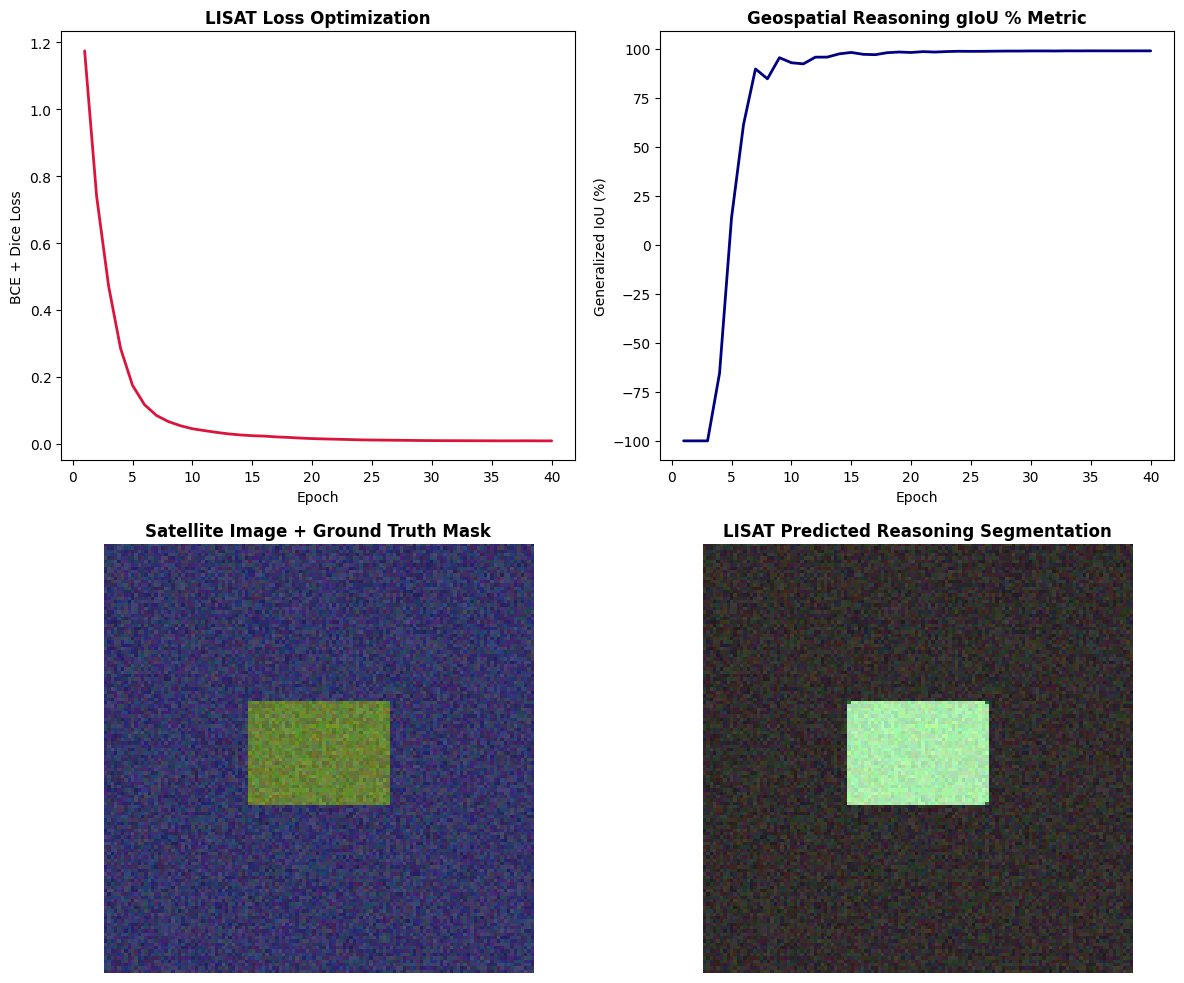


Evaluation complete. Visualizations successfully saved.


In [6]:
# [CELL 6 - Visualization & Segmentation Output Benchmark Plot]

lisat_model.eval()
with torch.no_grad():
    sample_idx = 2
    sample_img = test_imgs[sample_idx:sample_idx+1]
    sample_gt = test_masks[sample_idx].cpu().numpy().squeeze()
    sample_pid = test_pids[sample_idx:sample_idx+1]

    pred_logit = lisat_model(sample_img, sample_pid)
    pred_mask = (torch.sigmoid(pred_logit) > 0.5).float().cpu().numpy().squeeze()

# Convert tensor image for visualization
vis_img = sample_img.cpu().numpy().squeeze().transpose(1, 2, 0)
vis_img = np.clip(vis_img, 0, 1)

# Plotting Results
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.set_theme(style="whitegrid")

# Plot 1: Training Loss Curve
axes[0, 0].plot(range(1, num_epochs + 1), train_loss_hist, color='crimson', linewidth=2)
axes[0, 0].set_title("LISAT Loss Optimization", fontweight='bold')
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("BCE + Dice Loss")

# Plot 2: Validation gIoU Convergence
axes[0, 1].plot(range(1, num_epochs + 1), [g * 100 for g in val_giou_hist], color='navy', linewidth=2)
axes[0, 1].set_title("Geospatial Reasoning gIoU % Metric", fontweight='bold')
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Generalized IoU (%)")

# Plot 3: Input Satellite Image & Ground Truth Overlay
axes[1, 0].imshow(vis_img)
axes[1, 0].imshow(sample_gt, cmap='jet', alpha=0.4)
axes[1, 0].set_title("Satellite Image + Ground Truth Mask", fontweight='bold')
axes[1, 0].axis('off')

# Plot 4: Predicted LISAT Segmentation Mask
axes[1, 1].imshow(vis_img)
axes[1, 1].imshow(pred_mask, cmap='hot', alpha=0.5)
axes[1, 1].set_title("LISAT Predicted Reasoning Segmentation", fontweight='bold')
axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig("lisat_geospatial_benchmark.png", dpi=300)
plt.show()

print("\nEvaluation complete. Visualizations successfully saved.")